# Job Recommendation & Salary Analyzer
## Methodology & Preliminary Results

**What this notebook does**
1. Load the data
2. Explore the data (EDA) with charts
3. Check missing values and duplicates
4. Check outliers
5. Check skewness (is salary lopsided?)
6. Prepare features
7. Train simple salary models and compare them
8. Test whether skills can recommend a job title
9. Summary

## 0. Setup
Import the libraries and choose chart styles.

In [127]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

In [128]:
import os
os.makedirs("figures", exist_ok=True)   # folder for slide charts

## 1. Load the data

In [129]:
df = pd.read_csv("datasets/ai_job_dataset.csv")               # main dataset
df2 = pd.read_csv("datasets/ai_job_salary_dataset_10k.csv")   # second dataset (for checking only)

# Turn the date columns into real dates
df["posting_date"] = pd.to_datetime(df["posting_date"])
df["application_deadline"] = pd.to_datetime(df["application_deadline"])

print("Main dataset  :", df.shape[0], "rows,", df.shape[1], "columns")
print("Second dataset:", df2.shape[0], "rows,", df2.shape[1], "columns")
df.head()

Main dataset  : 15000 rows, 19 columns
Second dataset: 10000 rows, 7 columns


,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


### 1.1 Should we merge the two datasets?
**No.** The rows are different job postings, so there is no shared ID to join on. Also, the salaries in the two files are on different levels. The chart below compares median salary by country in each file.

           Main dataset  Second dataset
USA            128606.0        110792.0
UK             115281.0         88839.0
Germany        106923.0         92106.0
Canada         100392.0        101807.0
Australia      103205.5        101706.0
India           76035.0         34863.5


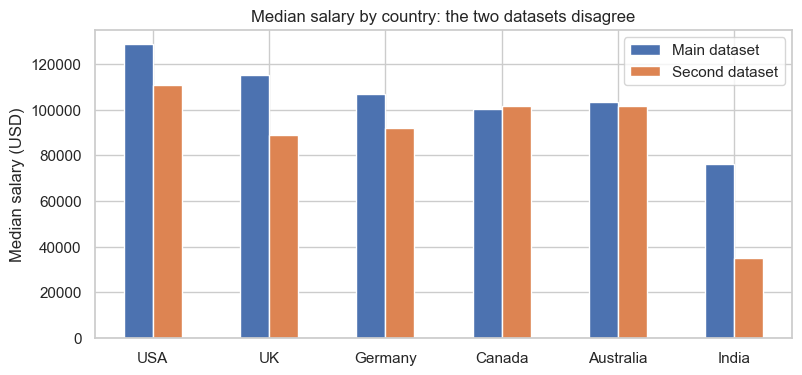

In [130]:
# Make the country names match between the two files
df["country_short"] = df["company_location"].replace({"United States": "USA", "United Kingdom": "UK"})
countries = ["USA", "UK", "Germany", "Canada", "Australia", "India"]

main_median = df[df["country_short"].isin(countries)].groupby("country_short")["salary_usd"].median()
second_median = df2.groupby("country")["salary_usd"].median()

compare = pd.DataFrame({"Main dataset": main_median, "Second dataset": second_median})
compare = compare.loc[countries]
print(compare)

compare.plot(kind="bar")
plt.title("Median salary by country: the two datasets disagree")
plt.ylabel("Median salary (USD)")
plt.xticks(rotation=0)
plt.show()

The two files agree on the ranking (the USA is high and India is low), but not on the amounts. For India, the difference is about 2×.
**Decision:** Use the main dataset for everything. Use the second one only as a quick check.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Basic info

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   job_id                  15000 non-null  object        
 1   job_title               15000 non-null  object        
 2   salary_usd              15000 non-null  int64         
 3   salary_currency         15000 non-null  object        
 4   experience_level        15000 non-null  object        
 5   employment_type         15000 non-null  object        
 6   company_location        15000 non-null  object        
 7   company_size            15000 non-null  object        
 8   employee_residence      15000 non-null  object        
 9   remote_ratio            15000 non-null  int64         
 10  required_skills         15000 non-null  object        
 11  education_required      15000 non-null  object        
 12  years_experience        15000 non-null  int64 

In [132]:
df.describe()

,salary_usd,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000,15000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,2024-08-29 08:48:51.840000,2024-10-11 21:55:23.520000,1503.314733,7.504273
min,32519.000000,0.000000,0.000000,2024-01-01 00:00:00,2024-01-16 00:00:00,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,2024-04-29 00:00:00,2024-06-13 00:00:00,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,2024-08-28 00:00:00,2024-10-12 00:00:00,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2024-12-29 00:00:00,2025-02-10 00:00:00,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2025-04-30 00:00:00,2025-07-11 00:00:00,2499.000000,10.000000
std,60260.940438,40.812712,5.545768,NaN,NaN,576.127083,1.450870


### 2.2 What does salary look like?

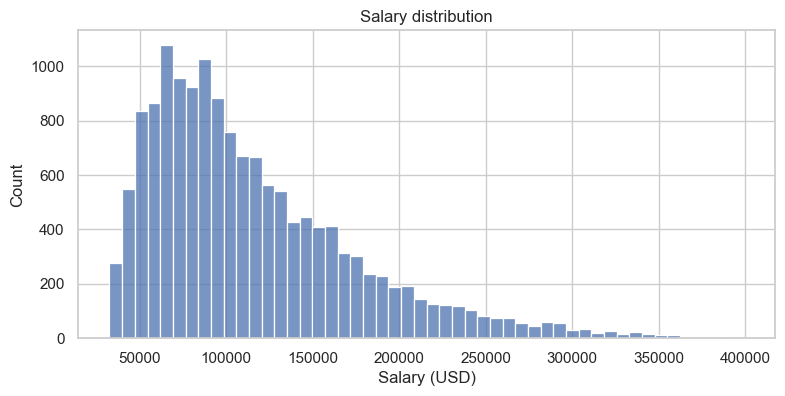

Average salary: 115349
Median salary : 99705


In [133]:
sns.histplot(df["salary_usd"], bins=50)
plt.title("Salary distribution")
plt.xlabel("Salary (USD)")
plt.show()

print("Average salary:", round(df["salary_usd"].mean()))
print("Median salary :", round(df["salary_usd"].median()))

The chart has a long tail to the right: most salaries are $60k–$150k, and a few are much higher.

### 2.2.1 Salary in both datasets (histogram + boxplot)

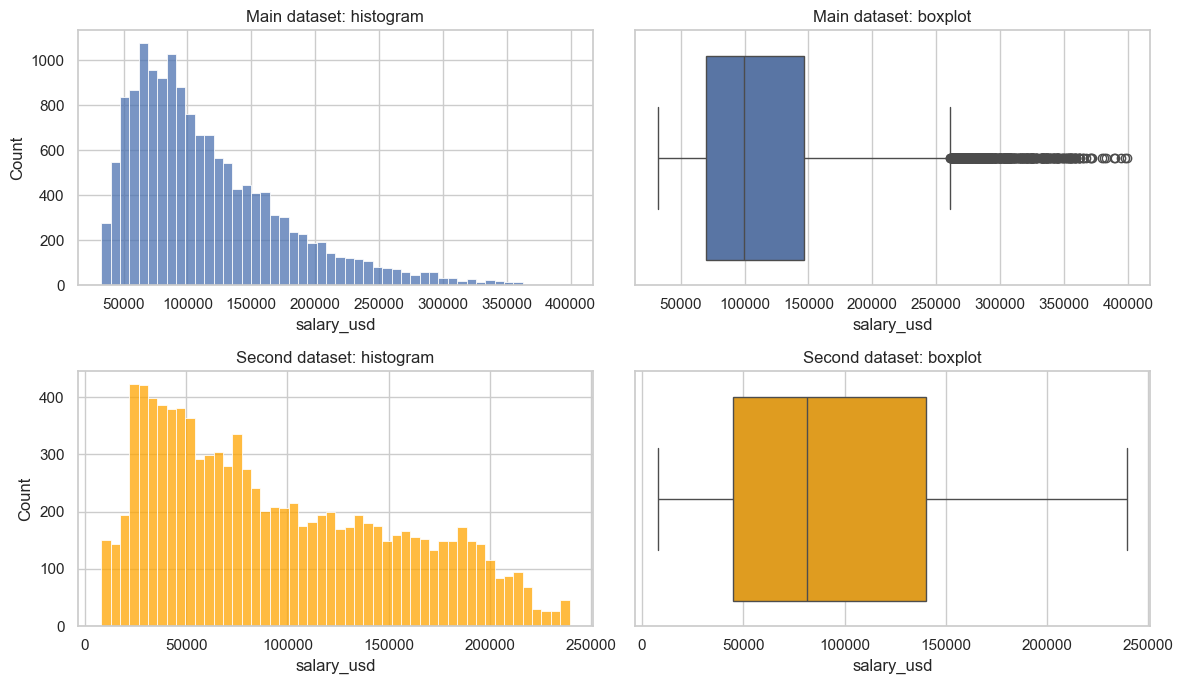

In [134]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

sns.histplot(df["salary_usd"], bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Main dataset: histogram")
sns.boxplot(x=df["salary_usd"], ax=axes[0, 1])
axes[0, 1].set_title("Main dataset: boxplot")

sns.histplot(df2["salary_usd"], bins=50, ax=axes[1, 0], color="orange")
axes[1, 0].set_title("Second dataset: histogram")
sns.boxplot(x=df2["salary_usd"], ax=axes[1, 1], color="orange")
axes[1, 1].set_title("Second dataset: boxplot")

plt.tight_layout()
plt.savefig("figures/E1_salary_distribution.png")
plt.show()

Both have a long right tail. The main dataset's salaries are higher overall.

### 2.3 Salary by experience level

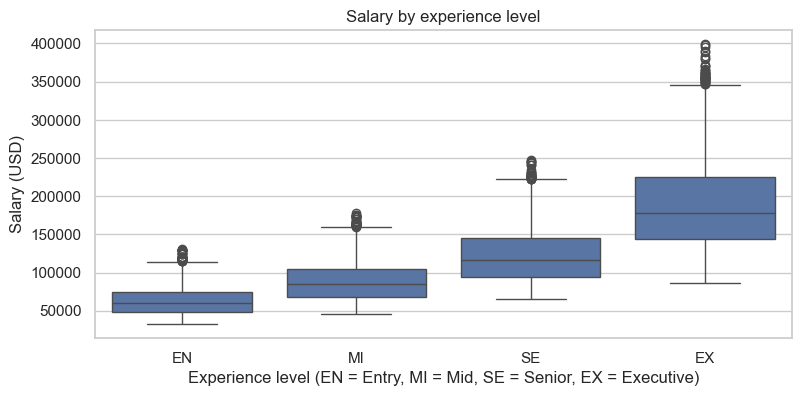

experience_level
EN     60373.5
MI     84641.0
SE    116907.0
EX    177512.0
Name: salary_usd, dtype: float64


In [135]:
level_order = ["EN", "MI", "SE", "EX"]   # Entry, Mid, Senior, Executive

sns.boxplot(data=df, x="experience_level", y="salary_usd", order=level_order)
plt.title("Salary by experience level")
plt.xlabel("Experience level (EN = Entry, MI = Mid, SE = Senior, EX = Executive)")
plt.ylabel("Salary (USD)")
plt.show()

print(df.groupby("experience_level")["salary_usd"].median().loc[level_order])

Salary rises clearly with experience. This is the strongest pattern in the data.

### 2.4 Salary by country

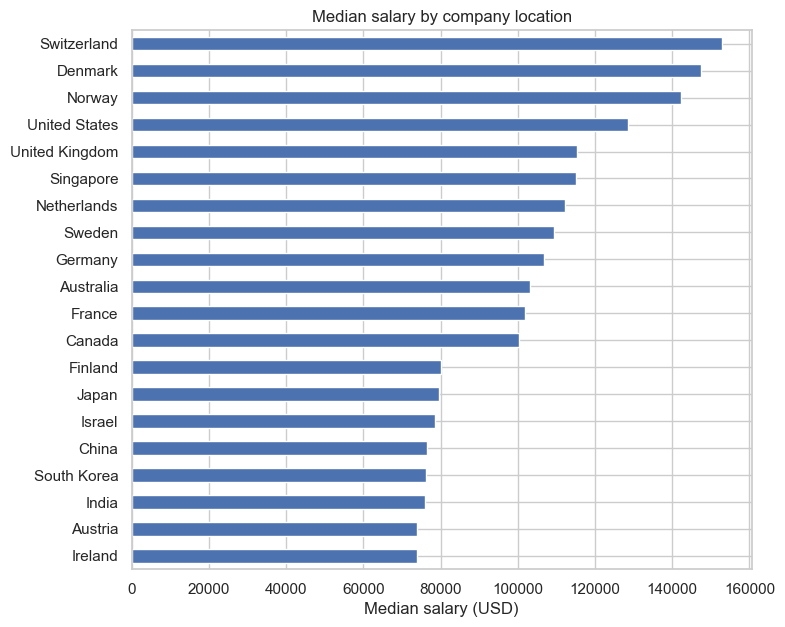

In [136]:
country_median = df.groupby("company_location")["salary_usd"].median().sort_values()

country_median.plot(kind="barh", figsize=(8, 7))
plt.title("Median salary by company location")
plt.xlabel("Median salary (USD)")
plt.ylabel("")
plt.show()

Location matters a lot. Switzerland and Denmark pay about twice as much as Ireland and Austria.

### 2.5 Which other columns affect salary?
The helper function below draws a bar chart of median salary for any column. If the bars are all about the same height, that column probably does not affect salary.

In [137]:
def plot_median_salary(column):
    medians = df.groupby(column)["salary_usd"].median().sort_values()
    medians.plot(kind="bar", figsize=(7, 3.5))
    plt.title("Median salary by " + column)
    plt.ylabel("Median salary (USD)")
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.show()

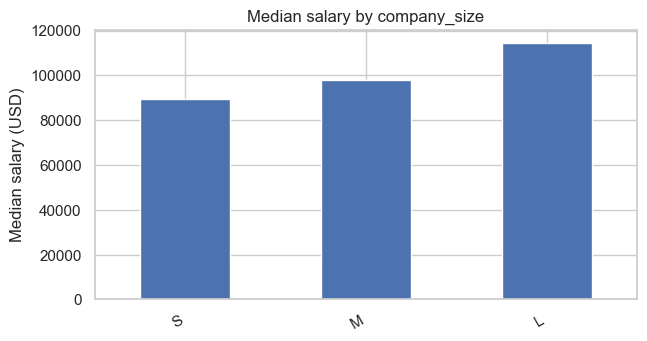

In [138]:
plot_median_salary("company_size")      # S = small, M = medium, L = large

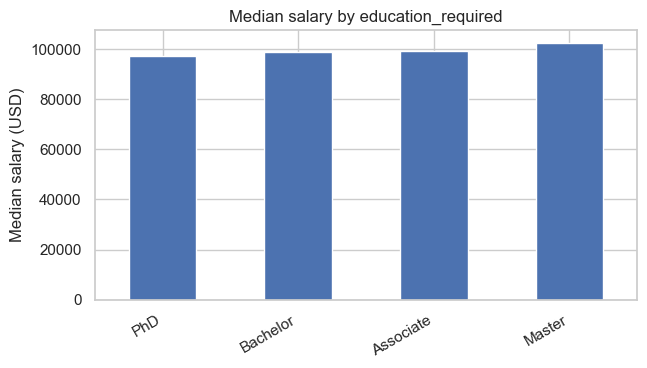

In [139]:
plot_median_salary("education_required")

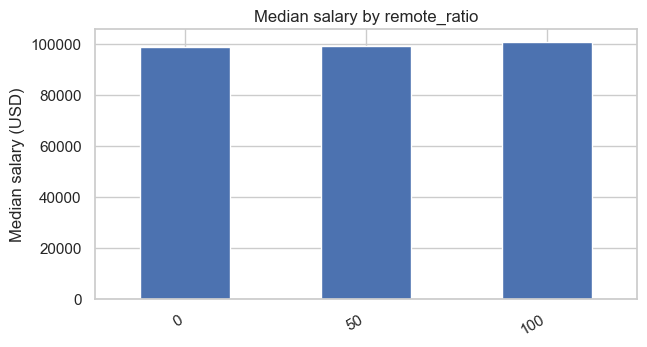

In [140]:
plot_median_salary("remote_ratio")      # 0 = on-site, 50 = hybrid, 100 = fully remote

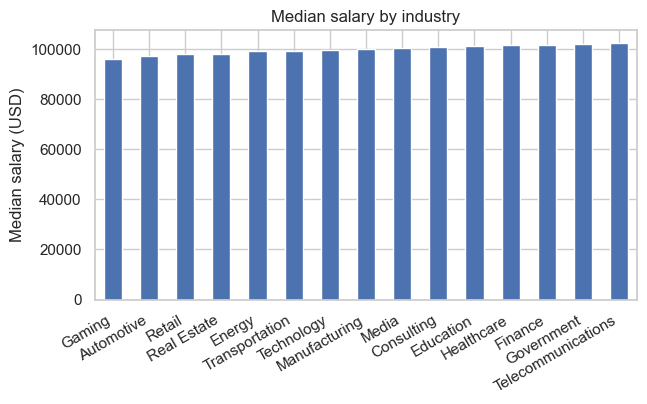

In [141]:
plot_median_salary("industry")


- **Company size** matters: large companies pay more.
- **Education, remote ratio and industry** barely change salary; all the bars are almost the same height.

### 2.5.1 Top 15 job titles and industries

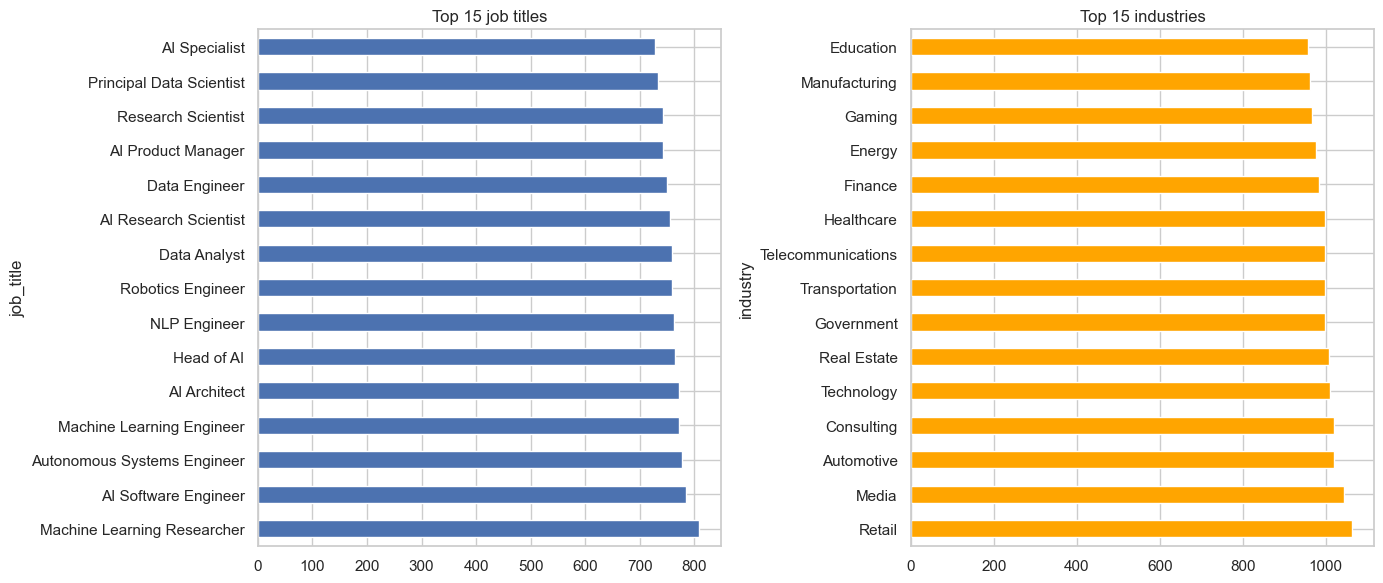

In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

df["job_title"].value_counts().head(15).plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 15 job titles")

df["industry"].value_counts().head(15).plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Top 15 industries")

plt.tight_layout()
plt.savefig("figures/E4_top_roles_industries.png")
plt.show()

All roles and industries have almost the same number of postings.

### 2.6 Numbers vs salary (correlation)

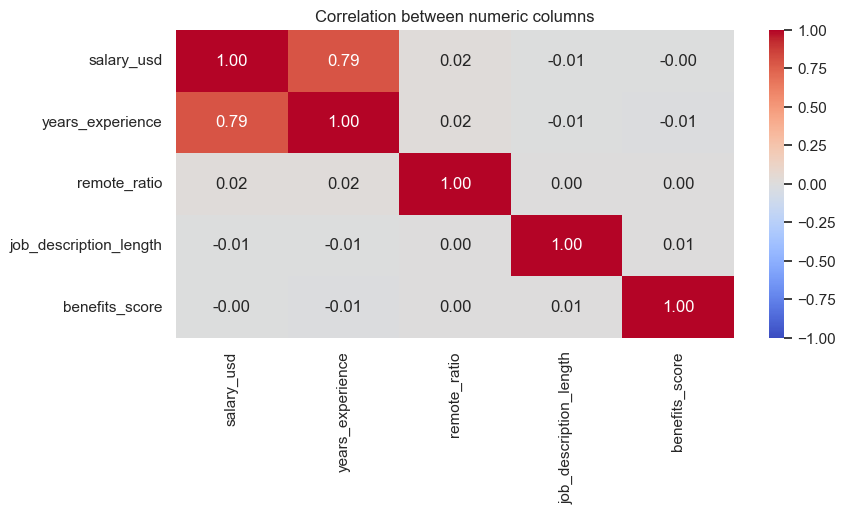

In [143]:
number_columns = ["salary_usd", "years_experience", "remote_ratio", "job_description_length", "benefits_score"]
corr = df[number_columns].corr(method="spearman")

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation between numeric columns")
plt.show()

Only `years_experience` is strongly related to salary (about 0.79). The other numeric columns are close to 0.

### 2.6.1 Correlation heatmap with market demand
**market_demand_score** = number of postings for the same job title in the same month (more postings = more demand).

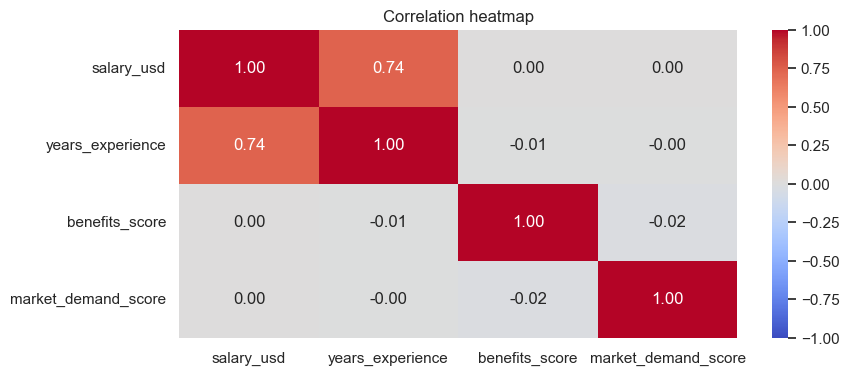

In [144]:
df["month"] = df["posting_date"].dt.to_period("M").astype(str)
df["market_demand_score"] = df.groupby(["job_title", "month"])["job_id"].transform("count")

cols = ["salary_usd", "years_experience", "benefits_score", "market_demand_score"]
sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation heatmap")
plt.savefig("figures/E5_correlation_heatmap.png", bbox_inches="tight")
plt.show()

Only years of experience is linked to salary. Market demand is close to 0.

### 2.7 Years of experience vs salary

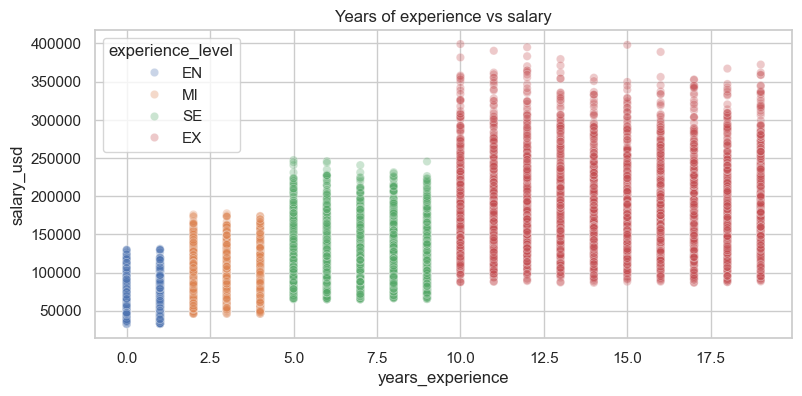

In [145]:
sns.scatterplot(data=df, x="years_experience", y="salary_usd", hue="experience_level",
                hue_order=level_order, alpha=0.3)
plt.title("Years of experience vs salary")
plt.show()

### 2.8 Skills

Number of different skills: 24
Skills per job (average): 4.0


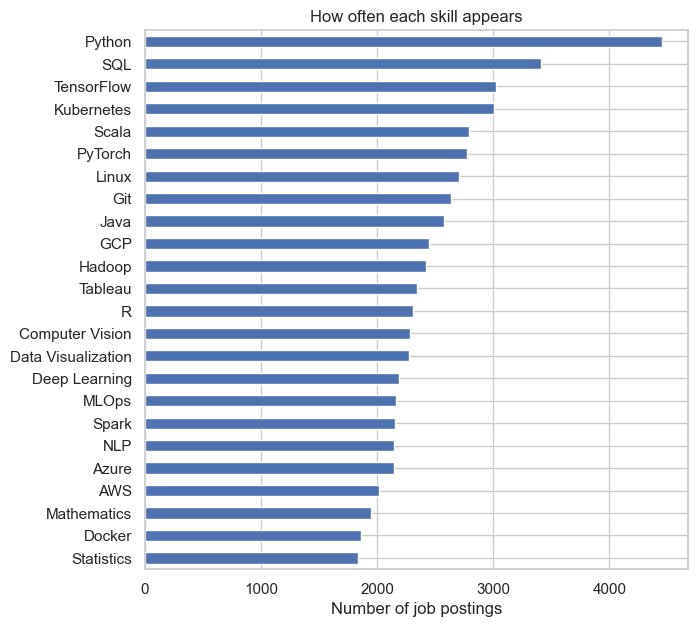

In [146]:
skills = df["required_skills"].str.get_dummies(sep=", ")

print("Number of different skills:", skills.shape[1])
print("Skills per job (average):", round(skills.sum(axis=1).mean(), 1))

skills.sum().sort_values().plot(kind="barh", figsize=(7, 7))
plt.title("How often each skill appears")
plt.xlabel("Number of job postings")
plt.savefig("figures/E6_top_skills.png", bbox_inches="tight")
plt.show()

The required_skills column looks like "Python, SQL, AWS, TensorFlow, Kubernetes".

**Do different jobs need different skills?**
The heatmap shows, for each job title, what percentage of its postings list each skill. If jobs had different skill needs, each row would look different from the others.

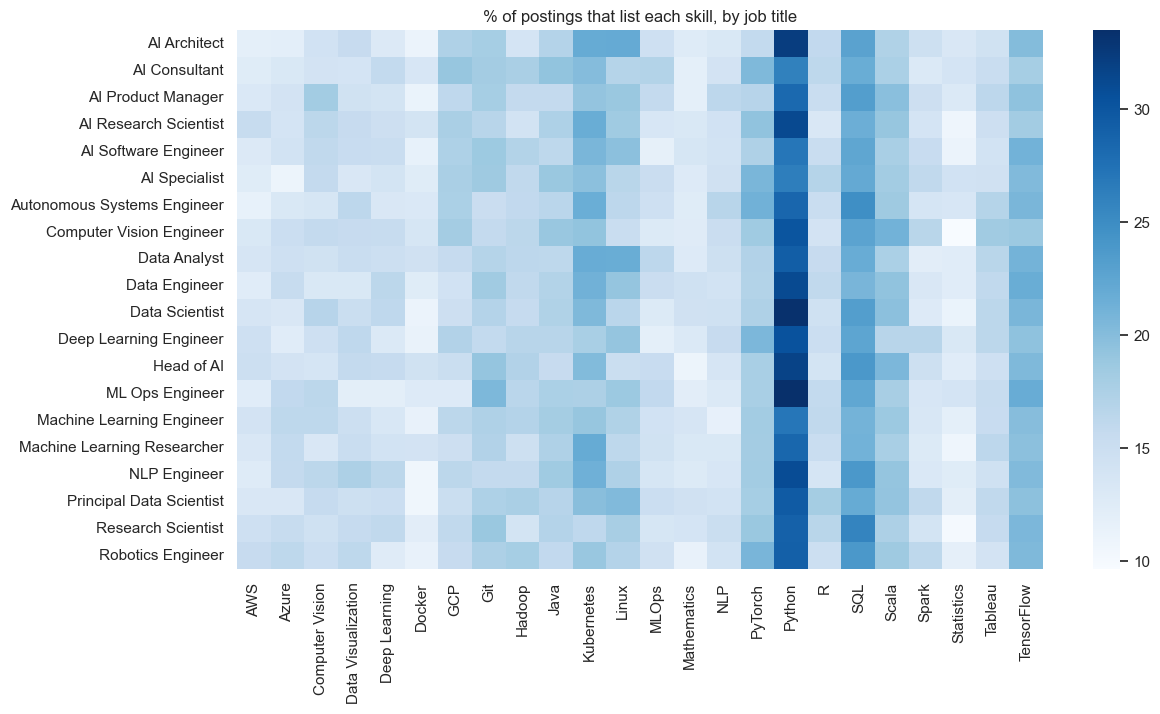

In [147]:
skill_percent = skills.groupby(df["job_title"]).mean() * 100

plt.figure(figsize=(13, 7))
sns.heatmap(skill_percent, cmap="Blues")
plt.title("% of postings that list each skill, by job title")
plt.xlabel(""); plt.ylabel("")
plt.show()

Every row looks almost the same. For example, a Data Analyst lists the same skills as a Robotics Engineer. In this dataset, skills do **not** tell us which job it is. Section 8 tests this with numbers.

### 2.9 Does salary change over time?

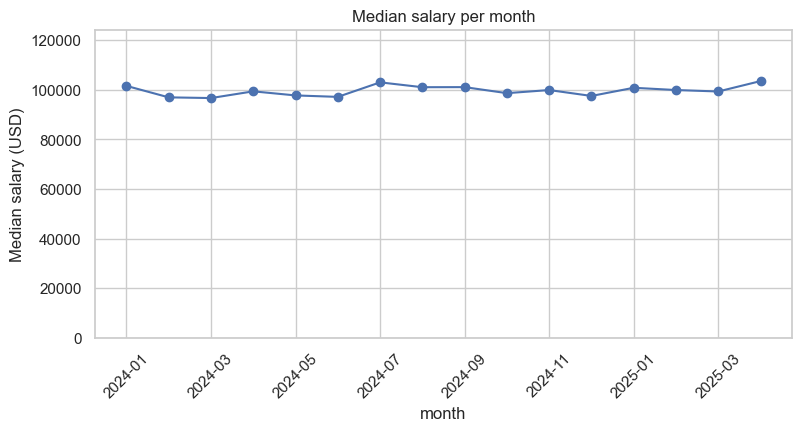

In [148]:
df["month"] = df["posting_date"].dt.to_period("M").astype(str)
monthly = df.groupby("month")["salary_usd"].median()

monthly.plot(marker="o")
plt.title("Median salary per month")
plt.ylabel("Median salary (USD)")
plt.xticks(rotation=45)
plt.ylim(0, monthly.max() * 1.2)
plt.show()

The line is almost flat, so salary does not change much over time. This means we can safely split the data by date: train on older postings and test on newer ones.

## 3. Missing values, duplicates and text cleaning

In [149]:
print("Missing values in main dataset  :", df.isnull().sum().sum())
print("Missing values in second dataset:", df2.isnull().sum().sum())
print("Duplicate rows in main dataset  :", df.drop(columns="job_id").duplicated().sum())

Missing values in main dataset  : 0
Missing values in second dataset: 0
Duplicate rows in main dataset  : 0


**Result:** There are no missing values and no duplicates, so nothing needs fixing here.
**Plan for the resume data later:** fill missing text columns with `"Unknown"` and missing numbers with the median.

### 3.1 Missing-value map

In [150]:
missing_percent = df.isnull().mean() * 100
missing_columns = missing_percent[missing_percent > 0].sort_values(ascending=False)

if missing_columns.empty:
    print("No columns have missing values.")
else:
    print("Columns with missing values:")
    print(missing_columns.round().to_string())

No columns have missing values.


Every column is 0% missing.

### 3.2 Remove duplicates

In [151]:
print("Rows before:", len(df))
df = df.drop_duplicates(subset=df.columns.drop("job_id"))   # same values in every column except the ID
print("Rows after :", len(df))

Rows before: 15000
Rows after : 15000


### 3.3 Missing-value rule (for future data)

In [152]:
# 1. Drop columns that are mostly empty
missing_share = df.isnull().mean()
df = df.drop(columns=missing_share[missing_share > 0.5].index)

# 2. Flag and fill the rest
for col in df.columns[df.isnull().any()]:
    df[col + "_was_missing"] = df[col].isnull().astype(int)
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

print("Missing values left:", df.isnull().sum().sum())

Missing values left: 0


### 3.4 Clean text fields

In [153]:
# Salary is already in USD (salary_currency is just the original currency)
print(df["salary_currency"].value_counts())

# Remove extra spaces
df["job_title"] = df["job_title"].str.strip()
df["industry"] = df["industry"].str.strip()

# Make skills always look like "Python, SQL, AWS" (regex)
df["required_skills"] = df["required_skills"].str.replace(r"\s*,\s*", ", ", regex=True)

# Same country names as the second dataset
df["company_location"] = df["company_location"].replace({"United States": "USA", "United Kingdom": "UK"})

salary_currency
USD    11957
EUR     2314
GBP      729
Name: count, dtype: int64


Salaries are already numbers in USD, so only small text fixes are needed.

## 4. Outliers
We use the **IQR rule**: a salary is an outlier if it is far above the 75th percentile or far below the 25th.

In [154]:
Q1 = df["salary_usd"].quantile(0.25)
Q3 = df["salary_usd"].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

df["is_outlier"] = df["salary_usd"] > upper_limit

print("Upper limit:", round(upper_limit))
print("Number of outliers:", df["is_outlier"].sum(), "(", round(df["is_outlier"].mean() * 100, 1), "% )")
print()
print("Outliers by experience level:")
print(df[df["is_outlier"]]["experience_level"].value_counts())

Upper limit: 260752
Number of outliers: 483 ( 3.2 % )

Outliers by experience level:
experience_level
EX    483
Name: count, dtype: int64


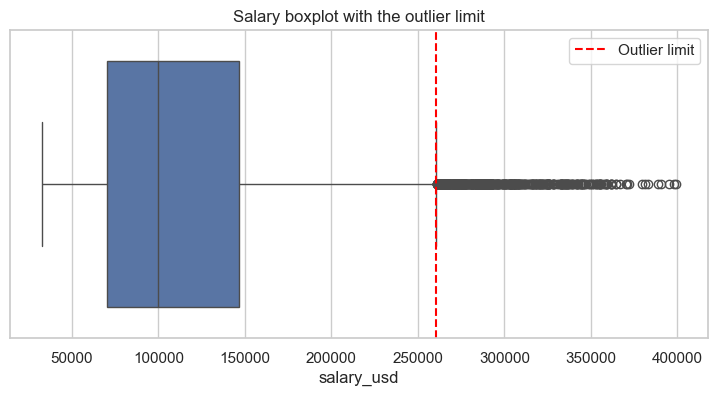

In [155]:
sns.boxplot(x=df["salary_usd"])
plt.axvline(upper_limit, color="red", linestyle="--", label="Outlier limit")
plt.title("Salary boxplot with the outlier limit")
plt.legend()
plt.show()

All outliers are **Executive (EX)** jobs, and high pay is normal for executives.
**Decision:** Keep them. Instead of deleting them, we use log(salary) in the next step, which reduces their effect.

### 4.1 Outliers within the same role + country
- **IQR:** far outside the middle 50% of that group
- **z-score:** more than 3 standard deviations from that group's average

In [156]:
group = df.groupby(["job_title", "company_location"])["salary_usd"]

# IQR method
q1 = group.transform(lambda x: x.quantile(0.25))
q3 = group.transform(lambda x: x.quantile(0.75))
df["outlier_iqr"] = (df["salary_usd"] < q1 - 1.5 * (q3 - q1)) | (df["salary_usd"] > q3 + 1.5 * (q3 - q1))

# z-score method
z = (df["salary_usd"] - group.transform("mean")) / group.transform("std")
df["outlier_z"] = z.abs() > 3

print("IQR outliers    :", df["outlier_iqr"].sum())
print("z-score outliers:", df["outlier_z"].sum())
print(df[df["outlier_iqr"]]["experience_level"].value_counts())

IQR outliers    : 394
z-score outliers: 39
experience_level
EX    393
SE      1
Name: count, dtype: int64


Again, almost all are Executive salaries, so they are real and we keep them.

## 5. Skewness
Skewness measures how lopsided a distribution is: 0 means balanced, and above 1 means a long right tail. Taking the **log** of salary usually fixes a long right tail.

Skewness of salary      : 1.25
Skewness of log(salary) : 0.14


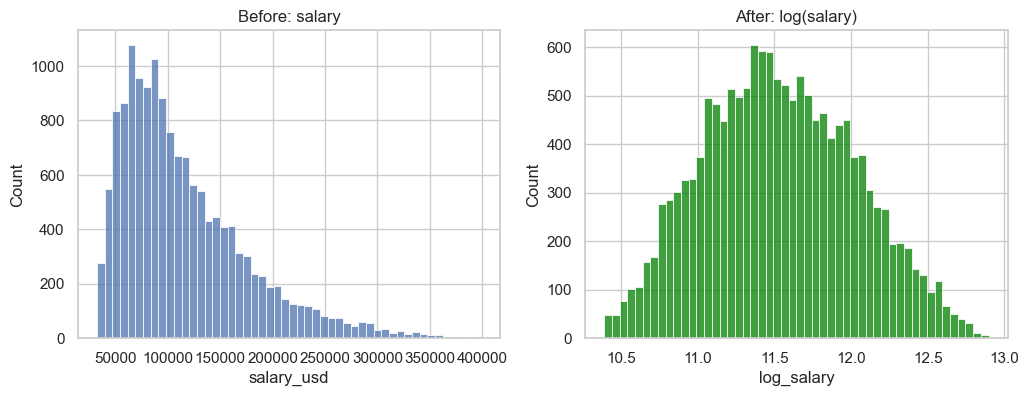

In [157]:
df["log_salary"] = np.log(df["salary_usd"])

print("Skewness of salary      :", round(df["salary_usd"].skew(), 2))
print("Skewness of log(salary) :", round(df["log_salary"].skew(), 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["salary_usd"], bins=50, ax=axes[0])
axes[0].set_title("Before: salary")
sns.histplot(df["log_salary"], bins=50, ax=axes[1], color="green")
axes[1].set_title("After: log(salary)")
plt.savefig("figures/E2_skewness.png", bbox_inches="tight")
plt.show()

**Result:** Skewness drops from about 1.25 to about 0.14. The models will predict log(salary), and we convert the predictions back to dollars afterwards.

## 6. Feature preparation

### 6.1 Two columns say the same thing
The table shows years of experience grouped into ranges for each experience level.

In [158]:
year_groups = pd.cut(df["years_experience"], bins=[-1, 1, 4, 9, 30], labels=["0-1", "2-4", "5-9", "10+"])
pd.crosstab(df["experience_level"], year_groups)

years_experience,0-1,2-4,5-9,10+
experience_level,,,,
EN,3718,0,0,0
EX,0,0,0,3760
MI,0,3781,0,0
SE,0,0,3741,0


Each experience level lines up with exactly one range of years. EN always means 0–1 years, MI always means 2–4, and so on. So the two columns carry the **same information**.

For now we keep both. A linear model like Ridge draws a straight line through `years_experience`, but real salaries jump between levels, and the `experience_level` columns let the model capture those jumps. (We tested this: without `experience_level`, Ridge's error goes up from about $14.5k to about $19k.)

### 6.2 Feature engineering
New columns made from existing ones.

In [159]:
df["days_to_deadline"] = (df["application_deadline"] - df["posting_date"]).dt.days   # days the job is open
df["num_skills"] = skills.sum(axis=1)                                                 # number of skills required
# market_demand_score was made in 2.6.1

df[["salary_usd", "days_to_deadline", "num_skills", "market_demand_score"]].corr()["salary_usd"].round(3)

salary_usd             1.000
days_to_deadline       0.013
num_skills            -0.013
market_demand_score    0.002
Name: salary_usd, dtype: float64

None of them are linked to salary, so we don't add them to the model.

### 6.3 Encode categoricals
- **Ordinal** (has an order) → numbers 0, 1, 2, …
- **One-hot** (no order) → one 0/1 column per category
- **Target encoding** (country) → the average salary of that country (see 6.6)

In [160]:
# Ordinal
df["company_size_ord"] = df["company_size"].map({"S": 0, "M": 1, "L": 2})
df["education_ord"] = df["education_required"].map({"Associate": 0, "Bachelor": 1, "Master": 2, "PhD": 3})

# One-hot
one_hot = pd.get_dummies(df[["job_title", "industry"]], dtype=int)
print("2 text columns became", one_hot.shape[1], "0/1 columns")
one_hot.head(3)

2 text columns became 35 0/1 columns


,job_title_AI Architect,job_title_AI Consultant,job_title_AI Product Manager,job_title_AI Research Scientist,job_title_AI Software Engineer,job_title_AI Specialist,job_title_Autonomous Systems Engineer,job_title_Computer Vision Engineer,job_title_Data Analyst,job_title_Data Engineer,...,industry_Gaming,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Real Estate,industry_Retail,industry_Technology,industry_Telecommunications,industry_Transportation
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 6.4 Build the model input (X) and target (y)
- Text columns → 0/1 columns with `pd.get_dummies`
- Skills → the 0/1 skill table from Section 2.8
- Target → `log_salary`

In [161]:
text_columns = ["job_title", "experience_level", "employment_type", "company_location", "company_size",
                "education_required", "industry"]
number_columns = ["years_experience", "remote_ratio", "job_description_length", "benefits_score"]

X = pd.concat([
    pd.get_dummies(df[text_columns]),   # text columns become 0/1 columns
    df[number_columns],                 # number columns stay as they are
    skills.add_prefix("skill_"),        # skill 0/1 columns
], axis=1)

y = df["log_salary"]
print("X has", X.shape[1], "columns")

X has 98 columns


### 6.5 Split by date (train on the past, test on the future)
This mimics real life: we learn from older job postings and predict newer ones.

In [162]:
cutoff_date = df["posting_date"].quantile(0.8)   # the first 80% of dates go to training

train = df["posting_date"] <= cutoff_date
test = df["posting_date"] > cutoff_date

X_train, y_train = X[train], y[train]
X_test,  y_test  = X[test],  y[test]

print("Cutoff date:", cutoff_date.date())
print("Train rows :", len(X_train))
print("Test rows  :", len(X_test))

Cutoff date: 2025-01-22
Train rows : 12002
Test rows  : 2998


### 6.6 Checks after the split

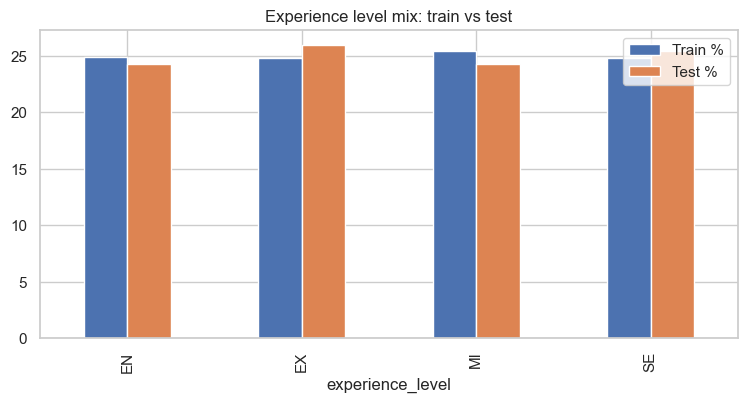

In [163]:
# Is the mix of experience levels the same in train and test?
pd.DataFrame({
    "Train %": df[train]["experience_level"].value_counts(normalize=True) * 100,
    "Test %": df[test]["experience_level"].value_counts(normalize=True) * 100,
}).round(1).plot(kind="bar")
plt.title("Experience level mix: train vs test")
plt.show()

# Target encoding: average log-salary per country (training rows only, to avoid leakage)
country_mean = df[train].groupby("company_location")["log_salary"].mean()
df["country_target"] = df["company_location"].map(country_mean)

Train and test have almost the same mix, so the date-based split is also balanced.

## 7. Salary models: preliminary results
We compare simple baselines with two real models:
1. **Guess the average:** predict the same salary for every job.
2. **Average by level:** predict the average salary of the job's experience level.
3. **Ridge regression:** a linear model.
4. **Random Forest:** a tree-based model.

**How we score them**
- **MAE:** on average, how many dollars the prediction is off by. Lower is better.
- **R²:** how much of the salary variation the model explains. 1.0 is perfect.

In [164]:
true_salary = df.loc[test, "salary_usd"]
results = []   # we store each model's score here

def score_model(name, predicted_log_salary):
    predicted_salary = np.exp(predicted_log_salary)   # convert log back to dollars
    mae = mean_absolute_error(true_salary, predicted_salary)
    r2 = r2_score(true_salary, predicted_salary)
    results.append({"Model": name, "MAE ($)": round(mae), "R2": round(r2, 3)})
    print(f"{name:25s}  MAE = ${mae:,.0f}   R2 = {r2:.3f}")

In [165]:
# Baseline 1: guess the average salary for everyone
guess = np.full(len(y_test), y_train.mean())
score_model("Guess the average", guess)

# Baseline 2: average salary of the job's experience level
level_average = df[train].groupby("experience_level")["log_salary"].mean()
guess = df.loc[test, "experience_level"].map(level_average)
score_model("Average by level", guess)

# Model 1: Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
score_model("Ridge regression", ridge.predict(X_test))

# Model 2: Random Forest
forest = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)
score_model("Random Forest", forest.predict(X_test))

Guess the average          MAE = $45,340   R2 = -0.055
Average by level           MAE = $28,168   R2 = 0.588
Ridge regression           MAE = $14,511   R2 = 0.887
Random Forest              MAE = $14,896   R2 = 0.879


In [166]:
# Model 3: Ridge with target-encoded country (1 column instead of 20)
X_te = X.drop(columns=X.filter(like="company_location_").columns)
X_te["country_target"] = df["country_target"]

ridge_te = Ridge(alpha=1.0)
ridge_te.fit(X_te[train], y_train)
score_model("Ridge (target encoding)", ridge_te.predict(X_te[test]))

Ridge (target encoding)    MAE = $14,543   R2 = 0.887


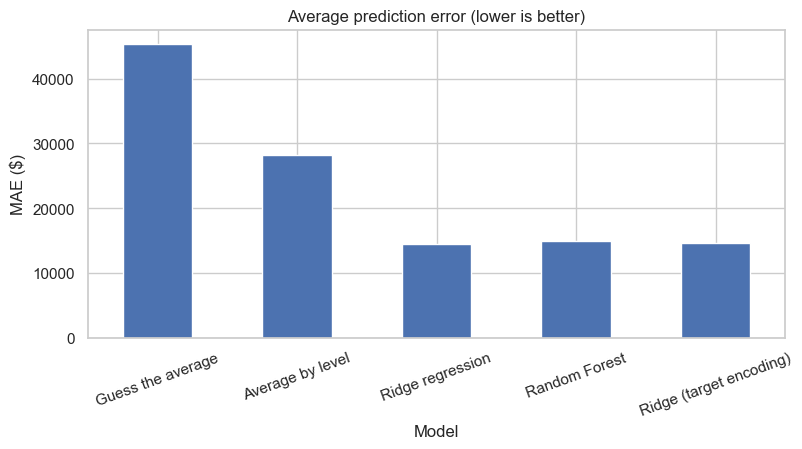

,Model,MAE ($),R2
0,Guess the average,45340,-0.055
1,Average by level,28168,0.588
2,Ridge regression,14511,0.887
3,Random Forest,14896,0.879
4,Ridge (target encoding),14543,0.887


In [167]:
results_table = pd.DataFrame(results)

results_table.plot(kind="bar", x="Model", y="MAE ($)", legend=False)
plt.title("Average prediction error (lower is better)")
plt.ylabel("MAE ($)")
plt.xticks(rotation=20)
plt.show()

results_table

Both models are off by about **$15k** on average, compared with about $28k for the level-average baseline. Salary prediction works.

### 7.1 Which features does the model use most?

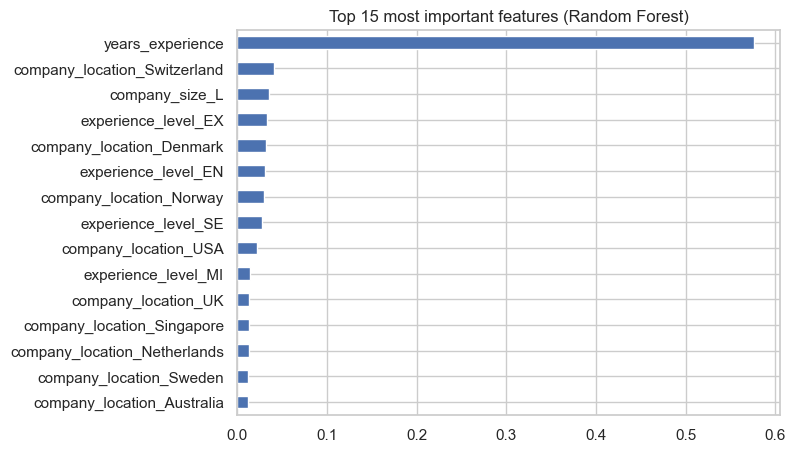

Total importance of ALL skills together: 0.012


In [168]:
importance = pd.Series(forest.feature_importances_, index=X.columns)

importance.sort_values().tail(15).plot(kind="barh", figsize=(7, 5))
plt.title("Top 15 most important features (Random Forest)")
plt.show()

print("Total importance of ALL skills together:", round(importance.filter(like="skill_").sum(), 3))

Years of experience, location and company size do most of the work. **Skills are almost useless** for predicting salary in this dataset.

## 8. Can skills recommend a job? (recommendation test)

**Idea:** for each job title, build an average skill profile from the training postings. Then, for each test posting, rank the 20 job titles by how similar their profiles are to the posting's skills. If skills are useful, the true job title should appear near the top.

**Scores**
- **Recall@K:** how often the true title appears in the top K.
- **Random guess:** K out of 20 titles, e.g. top 10 → 10/20 = 0.50.

In [169]:
from sklearn.metrics.pairwise import cosine_similarity

# Average skill profile of each job title (training data only)
title_profiles = skills[train].groupby(df.loc[train, "job_title"]).mean()

# How similar is each test posting to each job title?
similarity = cosine_similarity(skills[test], title_profiles)

# For each test posting: job titles sorted from most to least similar
ranked_titles = title_profiles.index.values[np.argsort(-similarity, axis=1)]
true_titles = df.loc[test, "job_title"].values

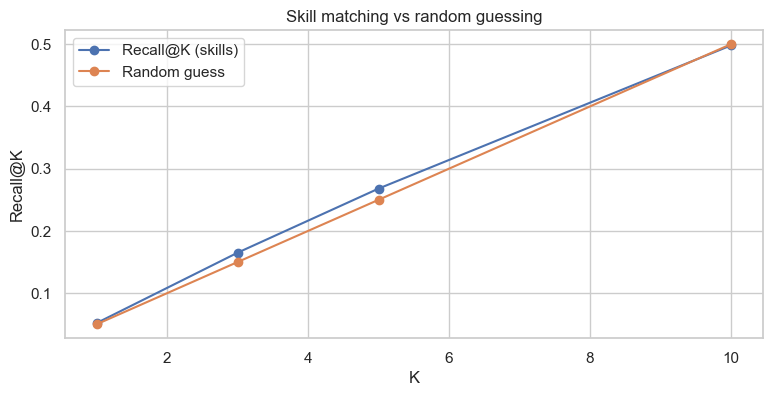

,K,Recall@K (skills),Random guess
0,1,0.052,0.05
1,3,0.165,0.15
2,5,0.268,0.25
3,10,0.498,0.50


In [170]:
rows = []
for K in [1, 3, 5, 10]:
    hits = [true in top[:K] for true, top in zip(true_titles, ranked_titles)]   # is the true title in the top K?
    rows.append({"K": K, "Recall@K (skills)": round(np.mean(hits), 3), "Random guess": K / 20})

recall_table = pd.DataFrame(rows)
recall_table.plot(x="K", y=["Recall@K (skills)", "Random guess"], marker="o")
plt.title("Skill matching vs random guessing")
plt.ylabel("Recall@K")
plt.show()

recall_table

The two lines lie on top of each other, so skill matching is **no better than random guessing**. This dataset looks synthetic: its skills are not linked to job titles.

## 9. Summary

| Step | What we found | What we decided |
|---|---|---|
| Merging | The two files have no shared ID and different salary levels | Don't merge; use the second file as a check only |
| Missing values / duplicates | None | Rule ready for new data: drop if >50% missing, else fill + flag |
| Text cleaning | Salary already in USD | Tidy text and country names |
| Outliers | 3.2% overall (2.6% within role + country), almost all Executive salaries | Keep them and use log(salary) |
| Skewness | 1.25 → 0.14 after log | Predict log(salary) |
| Features | New features (demand, days open, skill count) ≈ 0 correlation | Not added to the model |
| Encoding | Target encoding = same accuracy as one-hot | Fewer columns |
| Split | Train and test have the same level mix | Keep the date-based split |
| Salary model | MAE ≈ $15k (level baseline: $28k) | Salary prediction works |